# 🎙️ Module 7 — Speech Emotion Classification using Machine Learning

**Project:** Speech Emotion Recognition System  
**Dataset:** RAVDESS — 1,440 clips, 264 features, 8 emotion classes  
**Goal:** Train, evaluate and compare three classical ML classifiers — Logistic Regression, Random Forest and Support Vector Machine.

---
### Pipeline
```
Feature Matrix (1440×264) → Label Encoding → Train/Test Split (80/20)
  → StandardScaler → LR  /  RF  /  SVM
  → Predictions → Metrics → Saved Models
```

## 7.1 — Imports & Configuration

In [1]:
import os, json, warnings, joblib, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection   import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing     import StandardScaler, LabelEncoder
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier
from sklearn.svm               import SVC
from sklearn.metrics           import (accuracy_score, precision_score,
                                        recall_score, f1_score,
                                        confusion_matrix, classification_report)
from sklearn.pipeline          import Pipeline

# ── Theme ──────────────────────────────────────────────────────────────────
DARK  = '#0d0d1a';  PANEL = '#12122a';  TEXT = '#e2e8f0'
plt.rcParams.update({
    'figure.facecolor': DARK,  'axes.facecolor': PANEL,
    'axes.labelcolor' : TEXT,  'text.color'    : TEXT,
    'xtick.color': '#9090b0',  'ytick.color'   : '#9090b0',
    'grid.color' : '#252545',  'font.size'     : 10,
})
sns.set_style('darkgrid')

ECOLORS = {
    'neutral':'#94a3b8','calm':'#22d3ee','happy':'#fbbf24','sad':'#60a5fa',
    'angry':'#f87171','fearful':'#c084fc','disgust':'#4ade80','surprised':'#fb923c'
}

# ── Paths ──────────────────────────────────────────────────────────────────
BASE      = os.path.dirname(os.path.abspath('__file__'))
DATA_PROC = os.path.join(BASE, '..', 'data', 'processed')
FEAT_DIR  = os.path.join(BASE, '..', 'features')
MODEL_DIR = os.path.join(BASE, '..', 'models')
REP_DIR   = os.path.join(BASE, '..', 'reports', 'evaluation')
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(REP_DIR,   exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE    = 0.20

print('✅ All imports successful!')

✅ All imports successful!


## 7.2 — Load Feature Matrix & Emotion Labels

In [2]:
X_raw = np.load(os.path.join(DATA_PROC, 'X_features.npy'))  # (1440, 264)
y_raw = np.load(os.path.join(DATA_PROC, 'y_labels.npy'))    # (1440,)
df    = pd.read_csv(os.path.join(FEAT_DIR, 'features_dataset.csv'))

with open(os.path.join(DATA_PROC, 'preprocessing_config.json')) as f:
    cfg = json.load(f)
EMOTIONS = cfg['emotion_classes']   # 8 labels

print('📋 Feature Matrix Overview')
print(f'   X shape     : {X_raw.shape}  (clips × features)')
print(f'   y shape     : {y_raw.shape}')
print(f'   Num classes : {len(EMOTIONS)}')
print(f'   Emotions    : {EMOTIONS}')
print()
print('📊 Class Distribution:')
for i, em in enumerate(EMOTIONS):
    cnt = int(np.sum(y_raw == i))
    bar = '█' * (cnt // 12)
    print(f'  {i}  {em:<10}  {cnt:>4}  {bar}')

📋 Feature Matrix Overview
   X shape     : (1440, 264)  (clips × features)
   y shape     : (1440,)
   Num classes : 8
   Emotions    : ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']

📊 Class Distribution:
  0  neutral       96  ████████
  1  calm         192  ████████████████
  2  happy        192  ████████████████
  3  sad          192  ████████████████
  4  angry        192  ████████████████
  5  fearful      192  ████████████████
  6  disgust      192  ████████████████
  7  surprised    192  ████████████████


## 7.3 — Encode Labels & Split Data

In [3]:
# Labels are already encoded 0–7; we just map to string names for reporting
le = LabelEncoder()
le.classes_ = np.array(EMOTIONS)
y_str = le.inverse_transform(y_raw)     # string array for reporting

# ── Stratified 80/20 split ─────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y_raw       # keep class proportions
)

print('✂️  Train / Test Split (Stratified)')
print(f'   Train : {X_train.shape[0]} samples  ({(1-TEST_SIZE)*100:.0f}%)')
print(f'   Test  : {X_test.shape[0]}  samples  ({TEST_SIZE*100:.0f}%)')
print(f'   Features per clip : {X_train.shape[1]}')
print()
print('Train class counts:')
for i, em in enumerate(EMOTIONS):
    print(f'  {em:<10}: {int(np.sum(y_train==i))}')

# ── Feature scaling (StandardScaler) ──────────────────────────────────────
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Save scaler for inference
joblib.dump(scaler,  os.path.join(MODEL_DIR, 'scaler.pkl'))
joblib.dump(le,      os.path.join(MODEL_DIR, 'label_encoder.pkl'))
print('\n✅ Scaler and LabelEncoder saved!')

✂️  Train / Test Split (Stratified)
   Train : 1152 samples  (80%)
   Test  : 288  samples  (20%)
   Features per clip : 264

Train class counts:
  neutral   : 77
  calm      : 154
  happy     : 154
  sad       : 154
  angry     : 153
  fearful   : 153
  disgust   : 154
  surprised : 153

✅ Scaler and LabelEncoder saved!


## 7.4 — Helper: Evaluate & Report

In [4]:
results = {}   # stores metrics for all models

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, emotions):
    """
    Fit model, predict on test set, compute all metrics.
    Stores results in global `results` dict.
    """
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    y_pred     = model.predict(X_te)
    pred_time  = (time.time() - t0 - train_time) / len(X_te) * 1000  # ms/sample

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_te, y_pred,    average='weighted', zero_division=0)
    f1   = f1_score(y_te, y_pred,        average='weighted', zero_division=0)
    cm   = confusion_matrix(y_te, y_pred)
    cr   = classification_report(y_te, y_pred, target_names=emotions, zero_division=0)

    results[name] = {
        'model'     : model,
        'y_pred'    : y_pred,
        'accuracy'  : acc,
        'precision' : prec,
        'recall'    : rec,
        'f1'        : f1,
        'cm'        : cm,
        'report'    : cr,
        'train_time': train_time,
    }

    print(f'\n{"─"*55}')
    print(f'  🤖  {name}')
    print(f'{"─"*55}')
    print(f'  Accuracy   : {acc*100:.2f}%')
    print(f'  Precision  : {prec*100:.2f}%')
    print(f'  Recall     : {rec*100:.2f}%')
    print(f'  F1-Score   : {f1*100:.2f}%')
    print(f'  Train time : {train_time:.2f}s')
    print()
    print(cr)
    return model


def plot_confusion_matrix(name, cm, emotions, save_path):
    fig, ax = plt.subplots(figsize=(10, 8))
    fig.patch.set_facecolor(DARK)
    ax.set_facecolor(PANEL)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=emotions, yticklabels=emotions,
                ax=ax, linewidths=0.5, linecolor='#1a1a2e',
                annot_kws={'size': 11, 'weight': 'bold'},
                cbar_kws={'shrink': 0.8})
    ax.set_xlabel('Predicted Emotion', fontsize=12)
    ax.set_ylabel('True Emotion',      fontsize=12)
    ax.set_title(f'{name} — Confusion Matrix', fontsize=13,
                 color='white', fontweight='bold')
    ax.tick_params(colors='white')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', color='white')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  color='white')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=DARK)
    plt.show()
    print(f'✅ Saved → {save_path}')


print('✅ Evaluation helpers defined.')

✅ Evaluation helpers defined.


## 7.5 — Model 1: Logistic Regression

In [5]:
lr_model = LogisticRegression(
    C           = 1.0,
    max_iter    = 1000,
    solver      = 'lbfgs',
    random_state= RANDOM_STATE,
    n_jobs      = -1
)

evaluate_model('Logistic Regression', lr_model,
               X_train_sc, y_train, X_test_sc, y_test, EMOTIONS)

# Save model
joblib.dump(lr_model, os.path.join(MODEL_DIR, 'logistic_regression.pkl'))
print('💾 Model saved → models/logistic_regression.pkl')


───────────────────────────────────────────────────────
  🤖  Logistic Regression
───────────────────────────────────────────────────────
  Accuracy   : 52.78%
  Precision  : 53.36%
  Recall     : 52.78%
  F1-Score   : 52.86%
  Train time : 0.30s

              precision    recall  f1-score   support

     neutral       0.38      0.47      0.42        19
        calm       0.59      0.63      0.61        38
       happy       0.44      0.42      0.43        38
         sad       0.42      0.45      0.44        38
       angry       0.52      0.59      0.55        39
     fearful       0.61      0.49      0.54        39
     disgust       0.59      0.53      0.56        38
   surprised       0.63      0.62      0.62        39

    accuracy                           0.53       288
   macro avg       0.52      0.52      0.52       288
weighted avg       0.53      0.53      0.53       288

💾 Model saved → models/logistic_regression.pkl


## 7.6 — Confusion Matrix: Logistic Regression

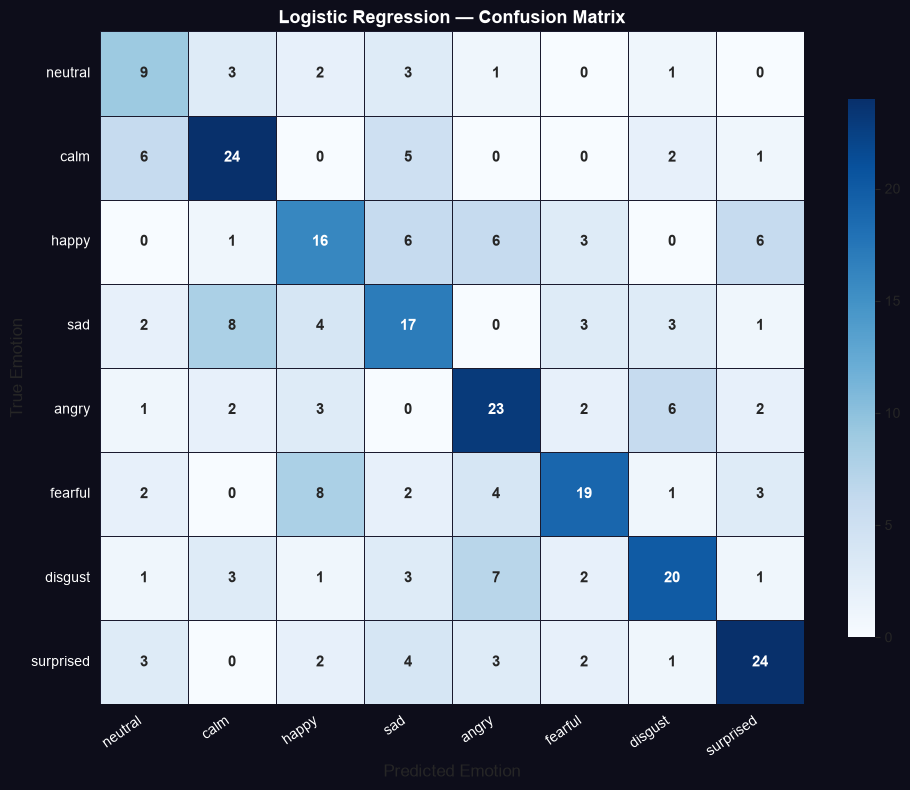

✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\evaluation\cm_logistic_regression.png


In [6]:
plot_confusion_matrix(
    'Logistic Regression',
    results['Logistic Regression']['cm'],
    EMOTIONS,
    os.path.join(REP_DIR, 'cm_logistic_regression.png')
)

## 7.7 — Model 2: Random Forest

In [7]:
rf_model = RandomForestClassifier(
    n_estimators = 300,
    max_depth    = None,
    min_samples_split = 2,
    min_samples_leaf  = 1,
    max_features = 'sqrt',
    random_state = RANDOM_STATE,
    n_jobs       = -1
)

# Note: RF doesn't need scaling — use raw features
evaluate_model('Random Forest', rf_model,
               X_train, y_train, X_test, y_test, EMOTIONS)

joblib.dump(rf_model, os.path.join(MODEL_DIR, 'random_forest.pkl'))
print('💾 Model saved → models/random_forest.pkl')


───────────────────────────────────────────────────────
  🤖  Random Forest
───────────────────────────────────────────────────────
  Accuracy   : 52.78%
  Precision  : 52.34%
  Recall     : 52.78%
  F1-Score   : 52.30%
  Train time : 0.64s

              precision    recall  f1-score   support

     neutral       0.31      0.26      0.29        19
        calm       0.58      0.74      0.65        38
       happy       0.42      0.37      0.39        38
         sad       0.47      0.45      0.46        38
       angry       0.56      0.64      0.60        39
     fearful       0.55      0.56      0.56        39
     disgust       0.66      0.55      0.60        38
   surprised       0.53      0.51      0.52        39

    accuracy                           0.53       288
   macro avg       0.51      0.51      0.51       288
weighted avg       0.52      0.53      0.52       288

💾 Model saved → models/random_forest.pkl


## 7.8 — Confusion Matrix: Random Forest

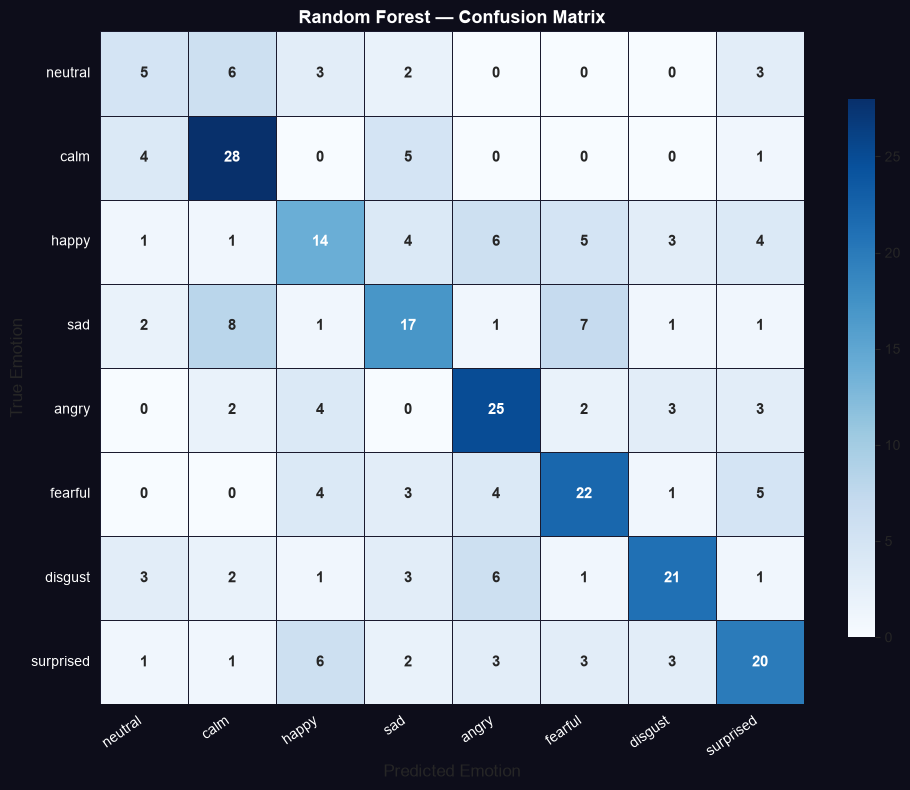

✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\evaluation\cm_random_forest.png


In [8]:
plot_confusion_matrix(
    'Random Forest',
    results['Random Forest']['cm'],
    EMOTIONS,
    os.path.join(REP_DIR, 'cm_random_forest.png')
)

## 7.9 — Model 3: Support Vector Machine

In [9]:
svm_model = SVC(
    C           = 10.0,
    kernel      = 'rbf',
    gamma       = 'scale',
    decision_function_shape = 'ovr',
    probability = True,
    random_state= RANDOM_STATE
)

evaluate_model('SVM', svm_model,
               X_train_sc, y_train, X_test_sc, y_test, EMOTIONS)

joblib.dump(svm_model, os.path.join(MODEL_DIR, 'svm_model.pkl'))
print('💾 Model saved → models/svm_model.pkl')


───────────────────────────────────────────────────────
  🤖  SVM
───────────────────────────────────────────────────────
  Accuracy   : 60.42%
  Precision  : 62.10%
  Recall     : 60.42%
  F1-Score   : 60.88%
  Train time : 0.73s

              precision    recall  f1-score   support

     neutral       0.38      0.63      0.47        19
        calm       0.60      0.63      0.62        38
       happy       0.65      0.58      0.61        38
         sad       0.48      0.53      0.50        38
       angry       0.74      0.64      0.68        39
     fearful       0.66      0.64      0.65        39
     disgust       0.62      0.53      0.57        38
   surprised       0.72      0.67      0.69        39

    accuracy                           0.60       288
   macro avg       0.60      0.61      0.60       288
weighted avg       0.62      0.60      0.61       288

💾 Model saved → models/svm_model.pkl


## 7.10 — Confusion Matrix: SVM

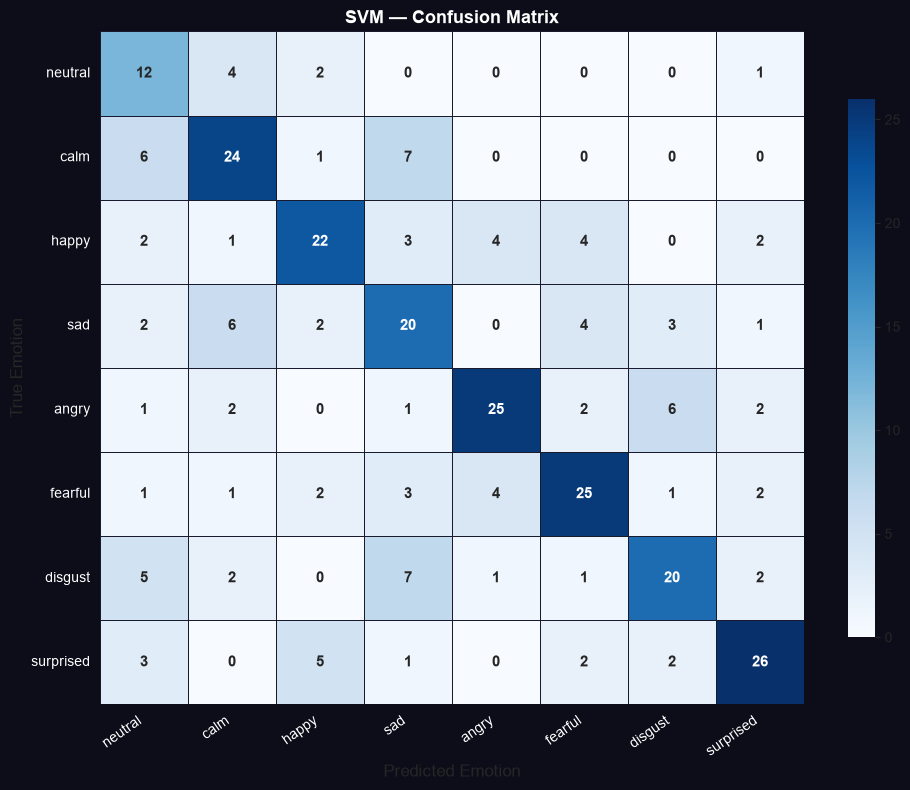

✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\evaluation\cm_svm.png


In [10]:
plot_confusion_matrix(
    'SVM',
    results['SVM']['cm'],
    EMOTIONS,
    os.path.join(REP_DIR, 'cm_svm.png')
)

## 7.11 — Cross-Validation Scores

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_configs = [
    ('Logistic Regression', lr_model, X_raw,    y_raw, True),
    ('Random Forest',       rf_model, X_raw,    y_raw, False),
    ('SVM',                 svm_model,X_raw,    y_raw, True),
]

cv_results = {}
print('📊 5-Fold Stratified Cross-Validation')
print('─' * 50)
for name, model, X_cv, y_cv, needs_scale in cv_configs:
    if needs_scale:
        from sklearn.pipeline import Pipeline
        pipe = Pipeline([('scaler', StandardScaler()), ('clf', model)])
        scores = cross_val_score(pipe, X_cv, y_cv, cv=cv,
                                  scoring='accuracy', n_jobs=-1)
    else:
        scores = cross_val_score(model, X_cv, y_cv, cv=cv,
                                  scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'  {name:<22}: {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%')
    print(f'    Folds: {[f"{s*100:.1f}%" for s in scores]}')

📊 5-Fold Stratified Cross-Validation
──────────────────────────────────────────────────


  Logistic Regression   : 56.18% ± 2.03%
    Folds: ['56.9%', '56.6%', '54.2%', '53.8%', '59.4%']


  Random Forest         : 55.90% ± 2.12%
    Folds: ['54.2%', '54.9%', '53.8%', '57.3%', '59.4%']


  SVM                   : 63.96% ± 3.05%
    Folds: ['59.0%', '64.9%', '62.8%', '64.6%', '68.4%']


## 7.12 — ML Model Comparison Dashboard

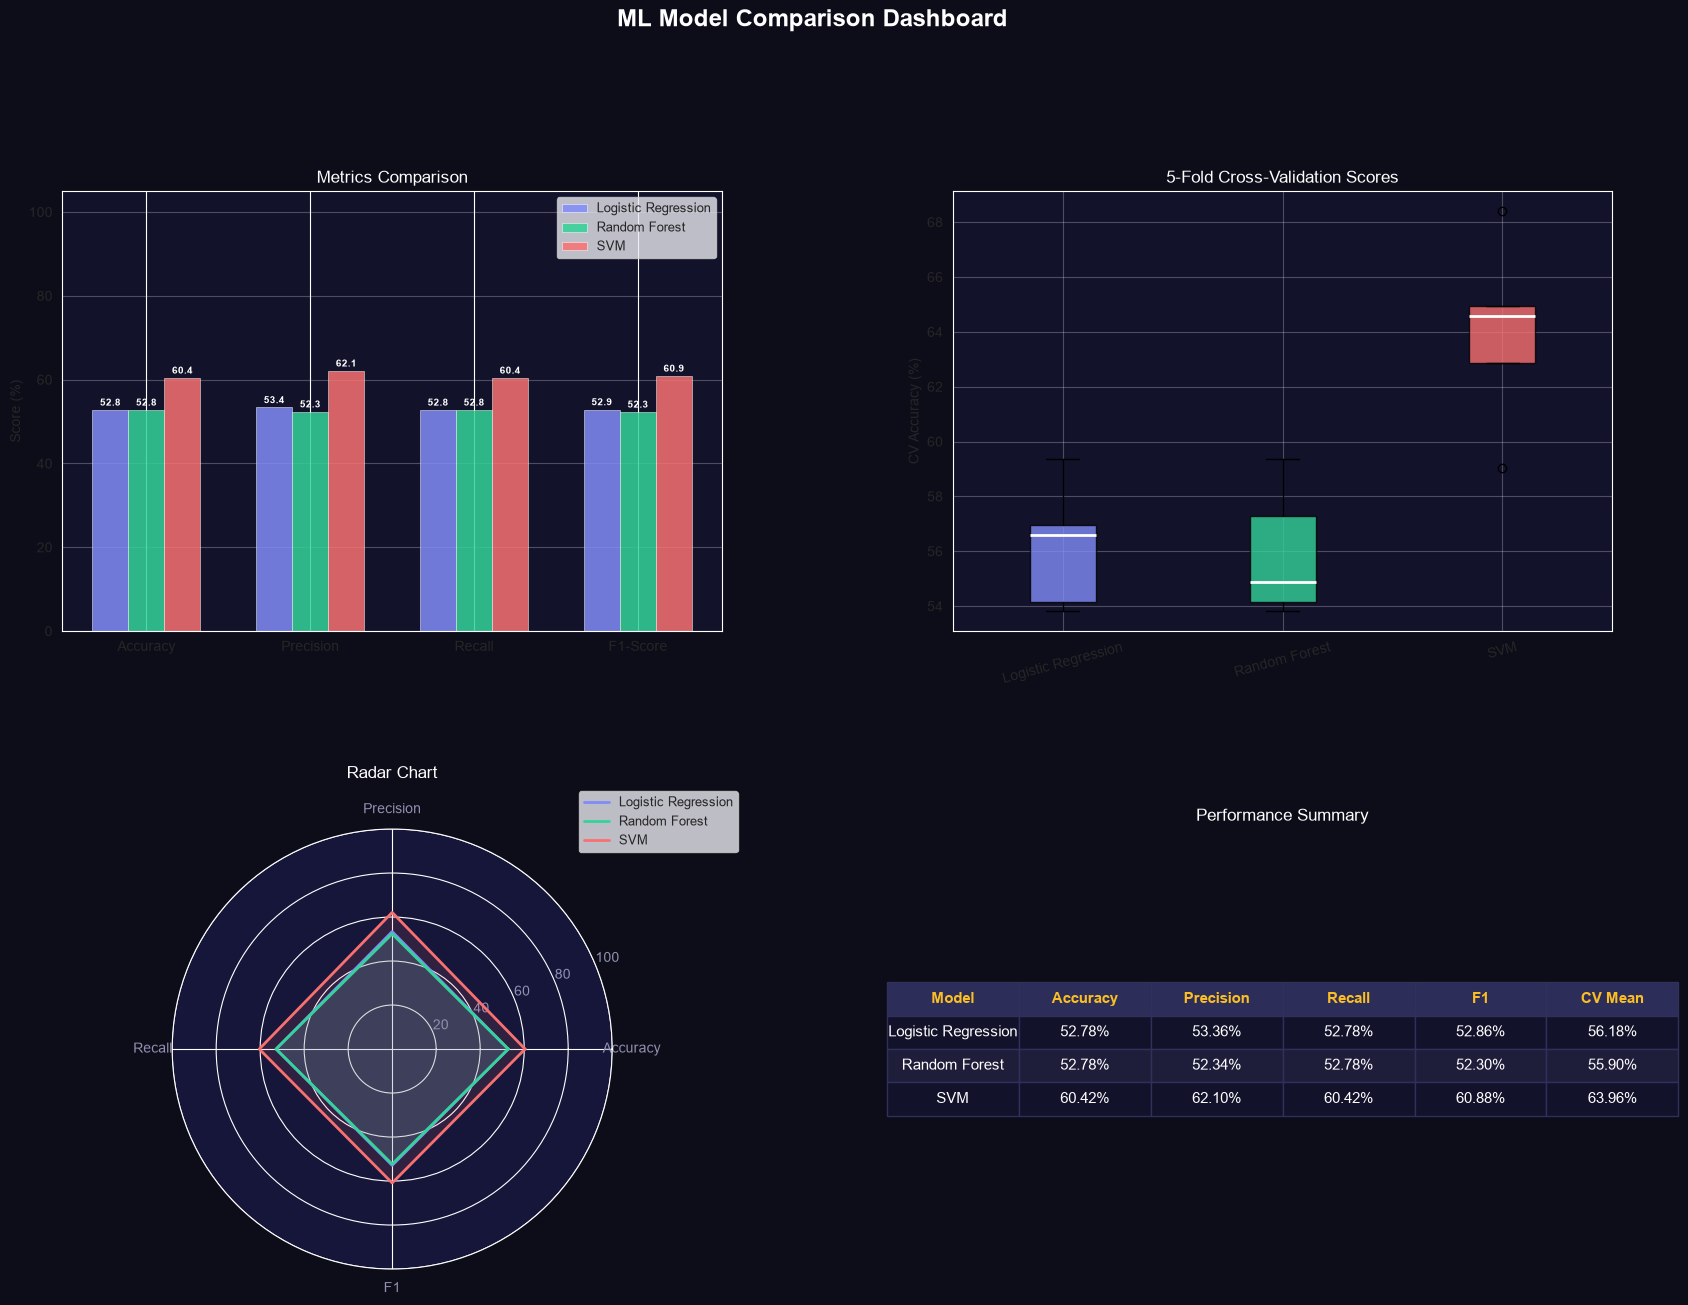

✅ Dashboard saved → C:\Speech Emotion Recognition\notebooks\..\reports\evaluation\ml_model_comparison_dashboard.png

🏆 Best ML model by F1-Score: SVM


In [12]:
model_names = list(results.keys())
metrics     = ['accuracy', 'precision', 'recall', 'f1']
colors_bar  = ['#818cf8', '#34d399', '#f87171']

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor(DARK)
fig.suptitle('ML Model Comparison Dashboard',
             fontsize=17, fontweight='bold', color='white', y=1.01)
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)

# ── (A) Accuracy / Precision / Recall / F1 grouped bar ────────────────────
ax_bar = fig.add_subplot(gs[0, 0])
ax_bar.set_facecolor(PANEL)
x   = np.arange(len(metrics))
w   = 0.22
for k, (name, col) in enumerate(zip(model_names, colors_bar)):
    vals = [results[name][m] * 100 for m in metrics]
    ax_bar.bar(x + k*w - w, vals, w, label=name, color=col, alpha=0.85,
               edgecolor='white', linewidth=0.4)
    for i, v in enumerate(vals):
        ax_bar.text(x[i]+k*w-w, v+0.5, f'{v:.1f}', ha='center',
                    va='bottom', fontsize=7.5, color='white', fontweight='bold')
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(['Accuracy','Precision','Recall','F1-Score'])
ax_bar.set_ylabel('Score (%)')
ax_bar.set_title('Metrics Comparison', color='white', fontsize=12)
ax_bar.set_ylim([0, 105])
ax_bar.legend(fontsize=9)
ax_bar.grid(axis='y', alpha=0.25)

# ── (B) CV score box plots ─────────────────────────────────────────────────
ax_cv = fig.add_subplot(gs[0, 1])
ax_cv.set_facecolor(PANEL)
cv_data = [cv_results[n]*100 for n in model_names]
bp = ax_cv.boxplot(cv_data, patch_artist=True,
                   medianprops={'color': 'white', 'linewidth': 2})
for patch, col in zip(bp['boxes'], colors_bar):
    patch.set_facecolor(col); patch.set_alpha(0.8)
ax_cv.set_xticks(range(1, len(model_names)+1))
ax_cv.set_xticklabels(model_names, rotation=15)
ax_cv.set_ylabel('CV Accuracy (%)')
ax_cv.set_title('5-Fold Cross-Validation Scores', color='white', fontsize=12)
ax_cv.grid(alpha=0.25)

# ── (C) Radar chart ───────────────────────────────────────────────────────
ax_rad = fig.add_subplot(gs[1, 0], polar=True)
ax_rad.set_facecolor('#16163a')
labels_rad = ['Accuracy','Precision','Recall','F1']
N_rad      = len(labels_rad)
angles     = np.linspace(0, 2*np.pi, N_rad, endpoint=False).tolist()
angles    += angles[:1]
for name, col in zip(model_names, colors_bar):
    vals = [results[name][m]*100 for m in metrics] + [results[name]['accuracy']*100]
    ax_rad.plot(angles, vals, color=col, linewidth=2, label=name)
    ax_rad.fill(angles, vals, color=col, alpha=0.12)
ax_rad.set_xticks(angles[:-1])
ax_rad.set_xticklabels(labels_rad, color='white', fontsize=10)
ax_rad.set_ylim([0, 100])
ax_rad.set_title('Radar Chart', color='white', fontsize=12, pad=18)
ax_rad.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
ax_rad.tick_params(colors='#9090b0')

# ── (D) Summary table ─────────────────────────────────────────────────────
ax_tbl = fig.add_subplot(gs[1, 1])
ax_tbl.set_facecolor(DARK)
ax_tbl.axis('off')
tbl_data  = []
tbl_cols  = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'CV Mean']
best_name = max(results, key=lambda n: results[n]['f1'])
for name in model_names:
    r = results[name]
    tbl_data.append([
        name,
        f'{r["accuracy"]*100:.2f}%',
        f'{r["precision"]*100:.2f}%',
        f'{r["recall"]*100:.2f}%',
        f'{r["f1"]*100:.2f}%',
        f'{cv_results[name].mean()*100:.2f}%'
    ])
tbl = ax_tbl.table(
    cellText   = tbl_data,
    colLabels  = tbl_cols,
    cellLoc    = 'center',
    loc        = 'center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 2.0)
for (r, c), cell in tbl.get_celld().items():
    cell.set_facecolor('#1e1e3a' if r % 2 == 0 else '#12122a')
    cell.set_text_props(color='white')
    cell.set_edgecolor('#30305a')
    if r == 0:
        cell.set_facecolor('#2d2d5a')
        cell.set_text_props(color='#fbbf24', fontweight='bold')
ax_tbl.set_title('Performance Summary', color='white', fontsize=12)

plt.tight_layout()
path = os.path.join(REP_DIR, 'ml_model_comparison_dashboard.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print(f'✅ Dashboard saved → {path}')
print(f'\n🏆 Best ML model by F1-Score: {best_name}')

## 7.13 — Per-Class F1 Score Breakdown

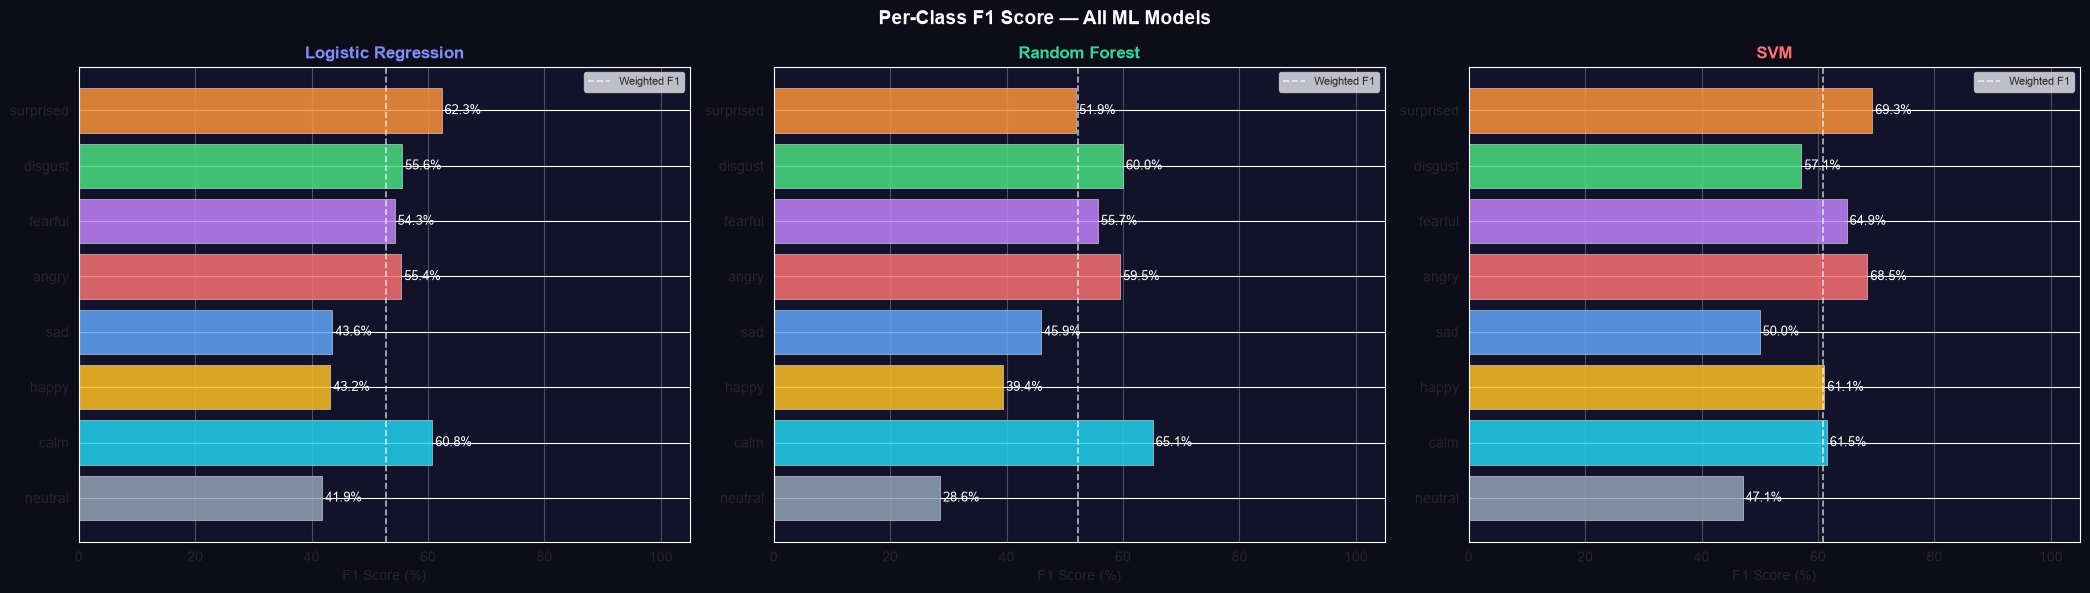

✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\evaluation\per_class_f1_ml_models.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.patch.set_facecolor(DARK)
fig.suptitle('Per-Class F1 Score — All ML Models', fontsize=14,
             fontweight='bold', color='white')

for ax, (name, col) in zip(axes, zip(model_names, colors_bar)):
    ax.set_facecolor(PANEL)
    y_pred  = results[name]['y_pred']
    f1_per  = f1_score(y_test, y_pred, average=None,
                        labels=range(len(EMOTIONS)), zero_division=0)
    clrs    = [ECOLORS[e] for e in EMOTIONS]
    bars    = ax.barh(EMOTIONS, f1_per * 100, color=clrs, alpha=0.85,
                      edgecolor='white', linewidth=0.4)
    for bar, val in zip(bars, f1_per * 100):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9, color='white')
    ax.set_xlim([0, 105])
    ax.set_xlabel('F1 Score (%)', fontsize=10)
    ax.set_title(name, color=col, fontweight='bold', fontsize=12)
    ax.grid(axis='x', alpha=0.25)
    ax.axvline(results[name]['f1']*100, color='white',
               linestyle='--', linewidth=1.2, alpha=0.7, label='Weighted F1')
    ax.legend(fontsize=8)

plt.tight_layout()
path = os.path.join(REP_DIR, 'per_class_f1_ml_models.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print(f'✅ Saved → {path}')

## 7.14 — Save Results & Module 7 Summary

In [14]:
# Save metrics to CSV for Module 9 comparison
metrics_rows = []
for name in model_names:
    r = results[name]
    metrics_rows.append({
        'model'     : name,
        'type'      : 'ML',
        'accuracy'  : round(r['accuracy'],  4),
        'precision' : round(r['precision'], 4),
        'recall'    : round(r['recall'],    4),
        'f1'        : round(r['f1'],        4),
        'cv_mean'   : round(cv_results[name].mean(), 4),
        'cv_std'    : round(cv_results[name].std(),  4),
    })
metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(os.path.join(REP_DIR, 'ml_metrics.csv'), index=False)

print('=' * 60)
print('   MODULE 7 — FINAL RESULTS SUMMARY')
print('=' * 60)
print(metrics_df.to_string(index=False))
print('=' * 60)
best = metrics_df.loc[metrics_df['f1'].idxmax()]
print(f'\n🏆 Best Model: {best["model"]}  |  F1={best["f1"]*100:.2f}%  |  Acc={best["accuracy"]*100:.2f}%')
print('\n📁 Saved Models:')
for f in os.listdir(MODEL_DIR):
    print(f'   {f}')
print('\n✅ Module 7 Complete!')

   MODULE 7 — FINAL RESULTS SUMMARY
              model type  accuracy  precision  recall     f1  cv_mean  cv_std
Logistic Regression   ML    0.5278     0.5336  0.5278 0.5286   0.5618  0.0203
      Random Forest   ML    0.5278     0.5234  0.5278 0.5230   0.5590  0.0212
                SVM   ML    0.6042     0.6210  0.6042 0.6088   0.6396  0.0305

🏆 Best Model: SVM  |  F1=60.88%  |  Acc=60.42%

📁 Saved Models:
   label_encoder.pkl
   logistic_regression.pkl
   random_forest.pkl
   scaler.pkl
   svm_model.pkl

✅ Module 7 Complete!
